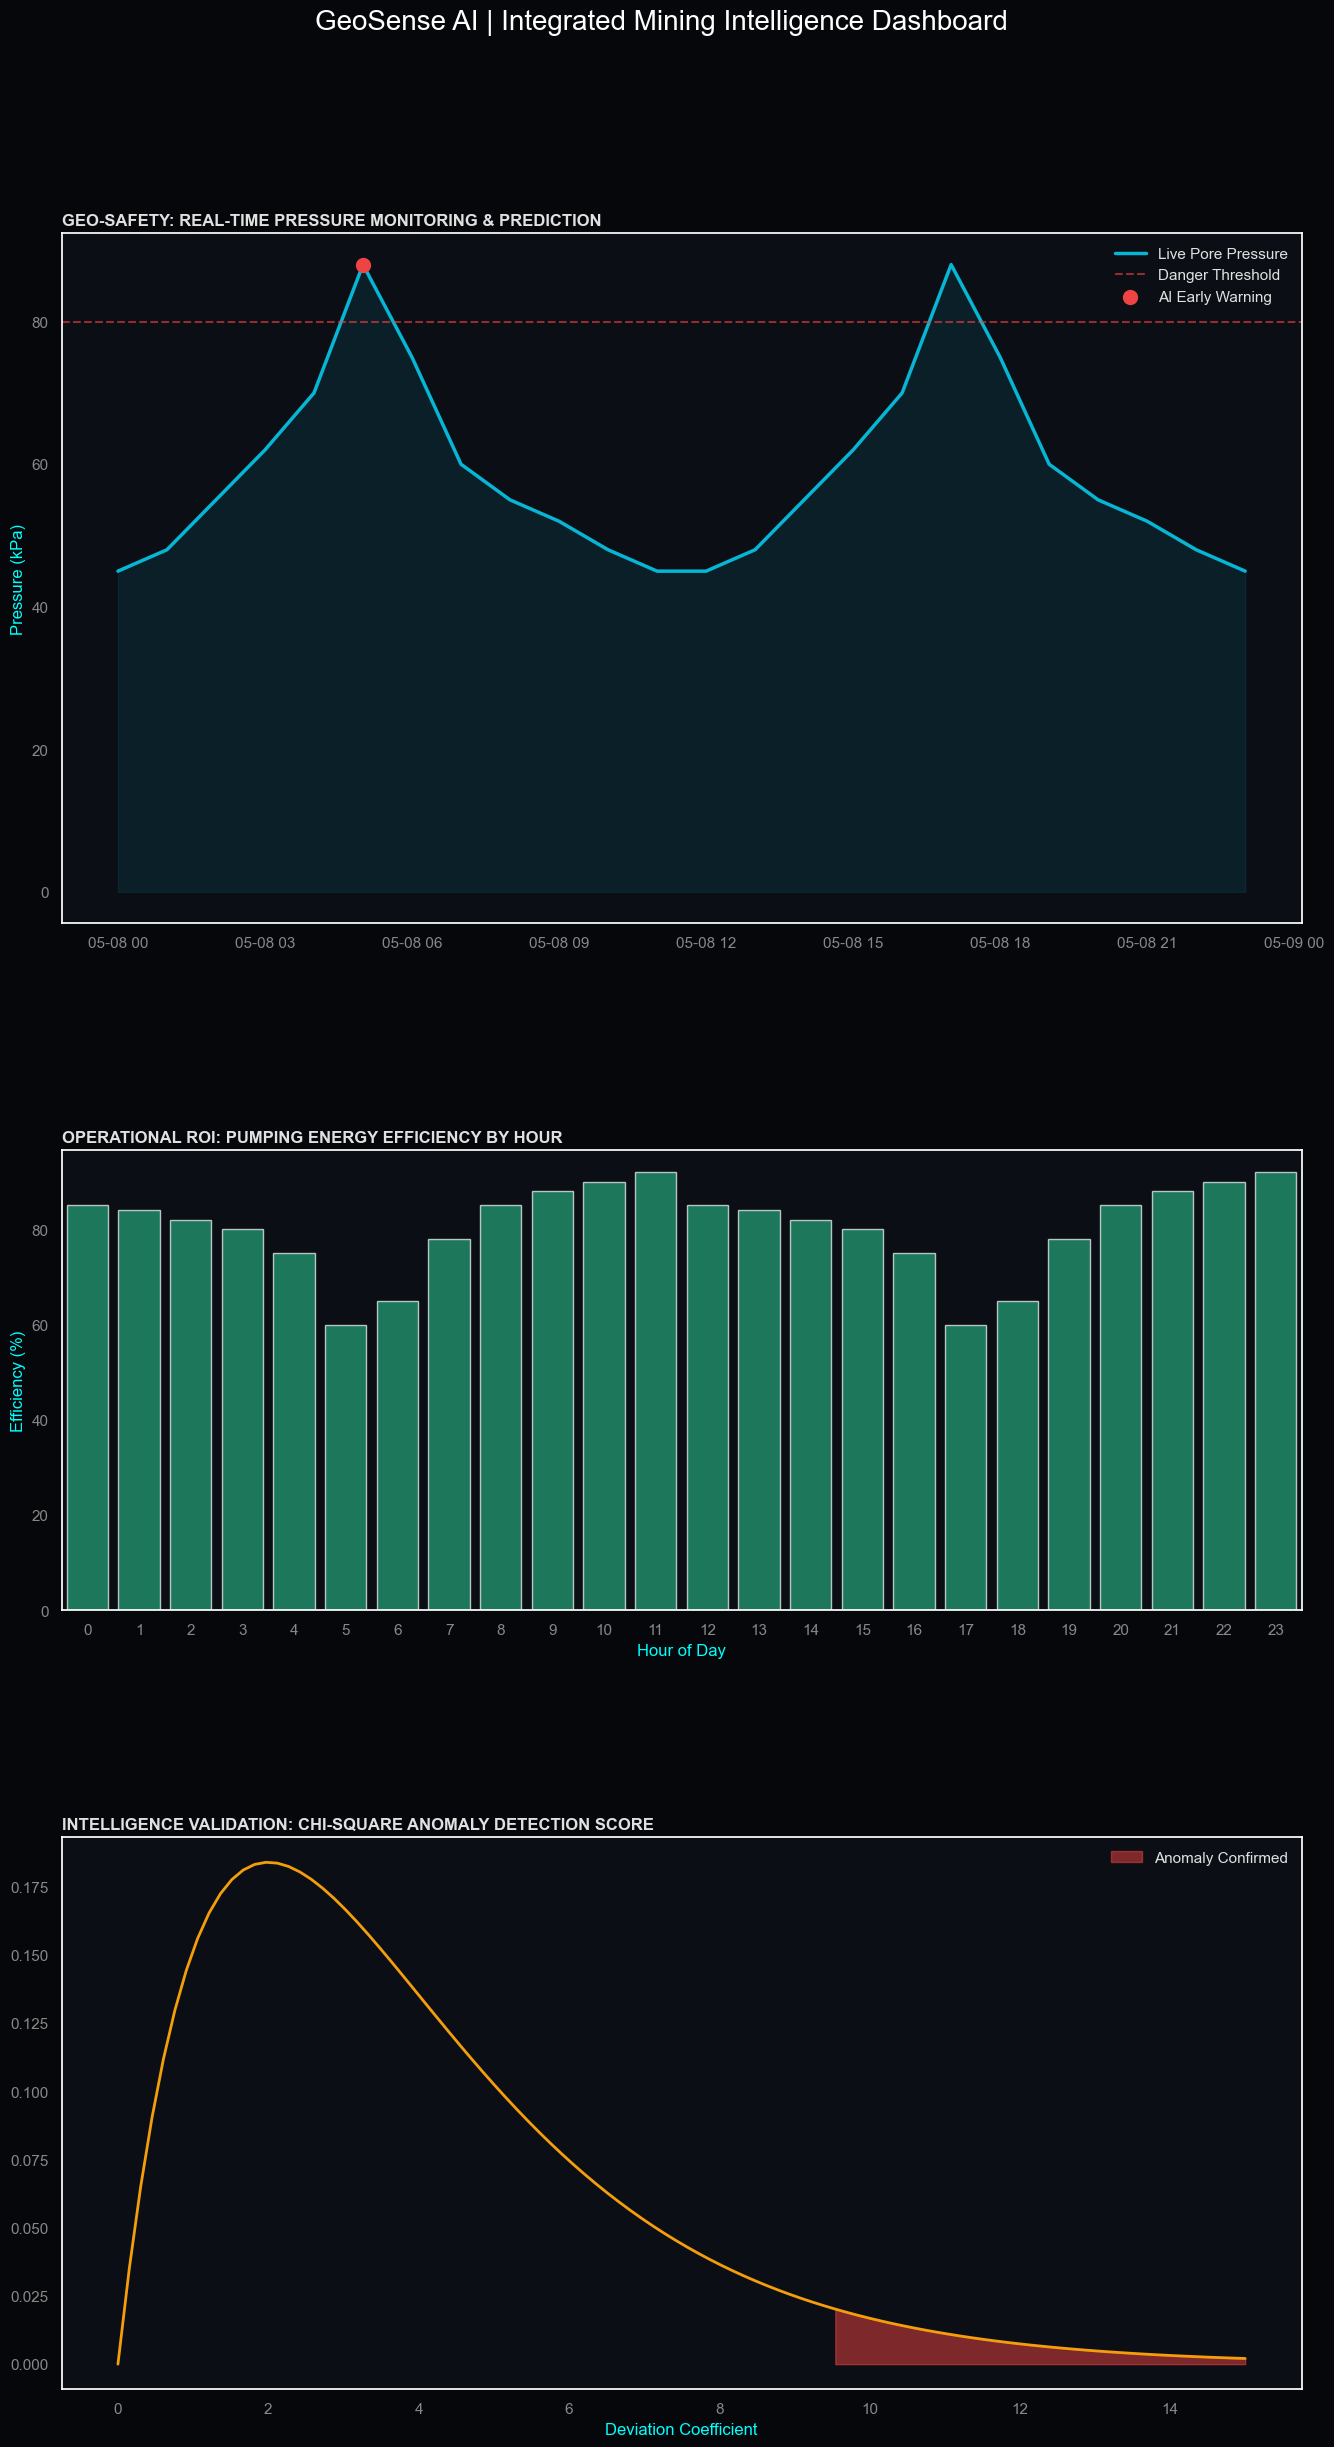

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats


sns.set_theme(style="dark")
plt.rcParams.update({
    'figure.facecolor': '#05070a',
    'axes.facecolor': '#0b0e14',
    'text.color': '#e0e0e0',
    'axes.labelcolor': '#00ffff',
    'xtick.color': '#888888',
    'ytick.color': '#888888',
    'grid.color': '#1f2937',
    'font.size': 10
})

#Time Series Data (24h period)
time = pd.date_range("2026-05-08", periods=24, freq="h")
pressure = [45, 48, 55, 62, 70, 88, 75, 60, 55, 52, 48, 45] * 2
energy_efficiency = [85, 84, 82, 80, 75, 60, 65, 78, 85, 88, 90, 92] * 2
df = pd.DataFrame({'Time': time, 'Pressure': pressure, 'Efficiency': energy_efficiency})

# Dashboard Layout
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 28), gridspec_kw={'height_ratios': [1.5, 1, 1.2]})
fig.subplots_adjust(hspace=0.4)

#PANEL 1: GEOLOGICAL SAFETY TREND
ax1.fill_between(df['Time'], df['Pressure'], color='#06b6d4', alpha=0.1)
ax1.plot(df['Time'], df['Pressure'], color='#06b6d4', linewidth=2.5, label='Live Pore Pressure')
ax1.axhline(y=80, color='#ef4444', linestyle='--', alpha=0.6, label='Danger Threshold')
ax1.scatter(df['Time'][5], 88, color='#ef4444', s=100, zorder=5, label='AI Early Warning')
ax1.set_title("GEO-SAFETY: REAL-TIME PRESSURE MONITORING & PREDICTION", loc='left', fontweight='bold')
ax1.set_ylabel("Pressure (kPa)")
ax1.legend(loc='upper right', frameon=False)

#PANEL 2: ENERGY OPTIMIZATION (ROI)
sns.barplot(x=df['Time'].dt.hour, y=df['Efficiency'], ax=ax2, color='#10b981', alpha=0.7)
ax2.set_title("OPERATIONAL ROI: PUMPING ENERGY EFFICIENCY BY HOUR", loc='left', fontweight='bold')
ax2.set_ylabel("Efficiency (%)")
ax2.set_xlabel("Hour of Day")

#PANEL 3: STATISTICAL RELIABILITY 
x_chi = np.linspace(0, 15, 100)
y_chi = stats.chi2.pdf(x_chi, df=4)
ax3.plot(x_chi, y_chi, color='#f59e0b', linewidth=2)
ax3.fill_between(x_chi, y_chi, where=(x_chi > 9.5), color='#ef4444', alpha=0.5, label='Anomaly Confirmed')
ax3.set_title("INTELLIGENCE VALIDATION: CHI-SQUARE ANOMALY DETECTION SCORE", loc='left', fontweight='bold')
ax3.set_xlabel("Deviation Coefficient")
ax3.legend(frameon=False)

plt.suptitle("GeoSense AI | Integrated Mining Intelligence Dashboard", fontsize=20, color='white', y=0.96)
plt.show()